<a href="https://colab.research.google.com/github/Rabindrajena/medical-insurance-cost-prediction/blob/main/Medical_Insurance_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Insurance Cost Prediction using Machine Learning

## Problem Statement
The objective of this project is to predict medical insurance charges based on demographic and lifestyle features such as age, BMI, smoking status, and region.

Accurate prediction of medical insurance costs can help insurance providers assess risk and design fair pricing stratergies.

We're given a [Csv file](https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv) containing verified historical data, consisting of the aforedmentioned information and the actual medical charges incurred by over 1300 customers.

## Dataset overview

The dataset contains the following features:

- **age**: Age of the insurance benificiary
- **sex**: Gender of the benificiary
- **bmi**: Body Mass Index
- **children**: Number of Dependents
- **snoker**: Smoking status
- **region**: Residential region
- **charges**: Medical insurance cost (target variable)

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('medical.csv')

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


The dataset contains 1338 rows and 7 columns. Each row of the dataset contains information about one customer.

our objective is to find a way to estimate the value in the "charges" column using the values in the other columns.
If we do so for the historical data, then we should able to estimate charges for new customers too, simply by asking for information like their age, BMI, no. of children, smoking habits and region.

Let's check the data type for each column.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Looks like "age", "children", "bmi" and "charges" are numbers, whereas "sex","smoker" and "region" are strings(possibly categories).None of the columns contain any missing values, which saves us a fair bit of work!

Here are some statistics for the numerical columns.

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#Exploratory Analysis and Visualization

In [7]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [8]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

#Age
The ranges of values in the numerical columns seem reasonable too(no negative ages!), so we may not have to do much data cleaning or correction.

The minimum age in the dataset is 18 and maximum age is 64. Thus, we can visualize the distribution of age using a histogram with 47 bins (one for each year) and a box plot.

**Interpretation**

* The population is **adult-only**, ranging from young adults (18) to near retirement(64).

* Mean ≈ Median → **age distribution is roughly symmetric**.

* Standard deviation of 14 years indicates **wide age diversity**.

**Insights**

* Older individuals are typically associated with **higher medical costs**.

* Age is likely a **strong predictor** of insurance charges.

* You may expect non-linear effects (charges increase faster after middle age).

In [9]:
fig = px.histogram(df, x='age',marginal='box',nbins=47,title='Distribution of Age',color_discrete_sequence=['green'])
fig.update_layout(bargap=0.1)
fig.show()

The distribution of ages in the dataset is almost uniform, with 20-30 customers at every age, except for the ages 18 and 19, which seem to over twice as many customers as other ages.

**Question:** Explain why there are over twice as many customers with ages 18 and 19, compared to other ages?

**Ans:**
The minimum age is 18 and the maximum age is 64, so i think the insurance company doesn't take the insurance less than 18 and more than 64 ages peoples.
While turning 18 is a natural entry point into insurance, the unusually high frequency at ages 18 and 19 likely reflects dataset sampling or generation choices, such as boundary oversampling or preprocessing effects.



#Body Mass Index

Let's look at the distribution of BMI of customers, using a histogram and box plot.

In [10]:
fig = px.histogram(df,x='bmi',marginal='box',color_discrete_sequence=['red'],title='Distribution of BMI(Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

The measurements of body mass index seem to form a [Gaussian Distribution](https://en.wikipedia.org/wiki/Normal_distribution) centered around the value 30, with a few outliers towards the right. Here's how BMI values can be interpreted [source](https://en.wikipedia.org/wiki/Body_mass_index):

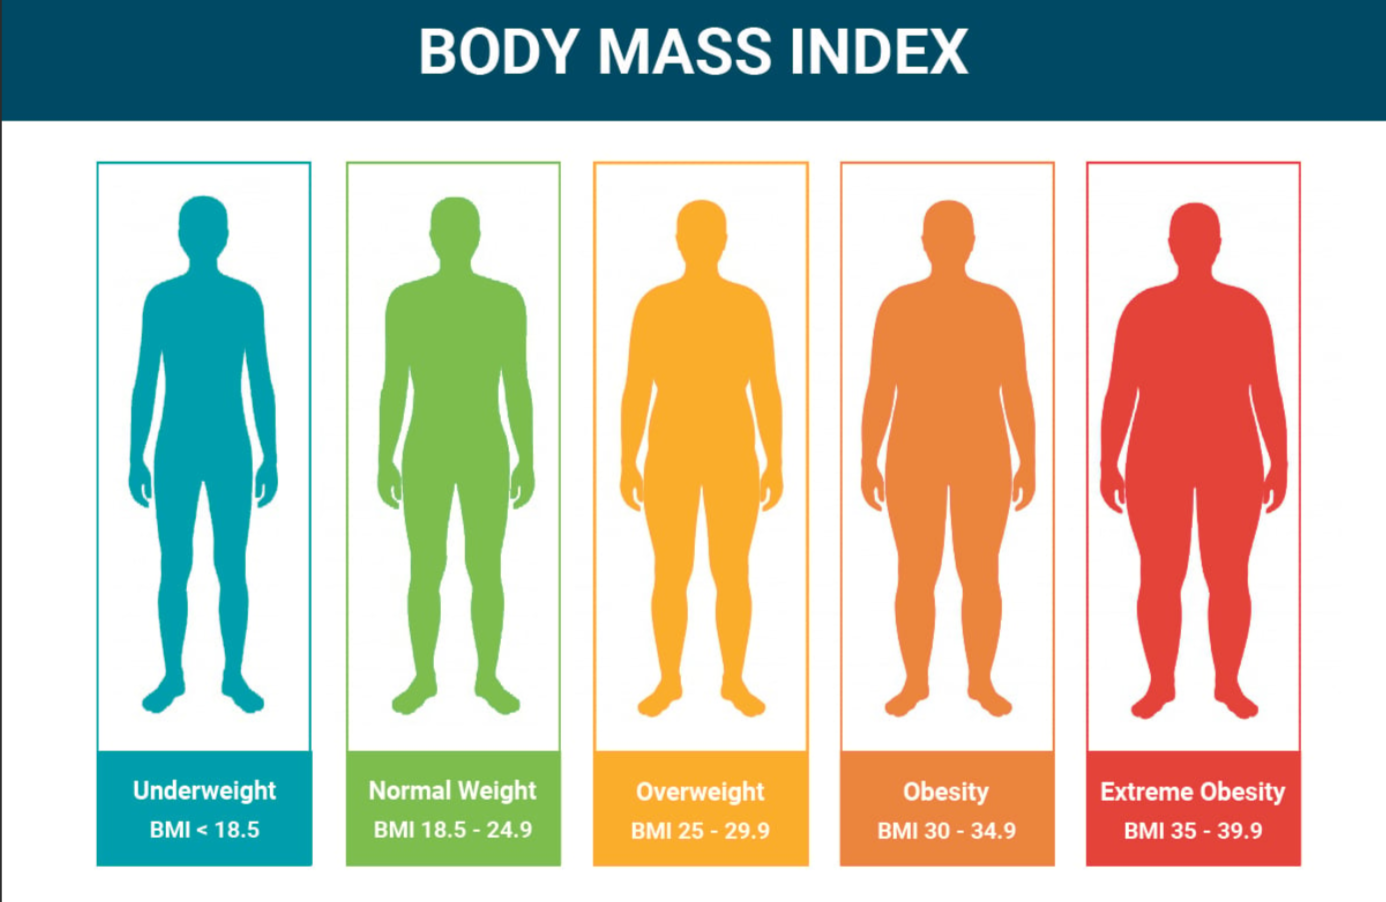

**Interpretation**

* Average BMI ≈ 30.66, which falls in the obese category (BMI ≥ 30).

* Median ≈ Mean → BMI is fairly symmetric but slightly right-skewed.

* Maximum BMI of 53 is **extremely obese**, indicating outliers.

**Health Interpretation**

BMI categories:

* Underweight: < 18.5

* Normal: 18.5 – 24.9

* Overweight: 25 – 29.9

* Obese: ≥ 30

👉 Most individuals are **overweight or obese**, implying:

* Higher risk of chronic disease

* Increased medical costs

**Insights**

* BMI likely has a **strong positive correlation** with charges.

* Possible **interaction effects** with age (older + obese → much higher costs).

* Presence of outliers suggests **robust models** or log transformation of charges.

**Question:** Explain why the distribution of ages forms a uniform distribution while the distribution of BMIs forms a gaussian distribution?
**Ans:** Age appears uniformly distributed because it is likely intentionally sampled to cover all age groups evenly, whereas BMI follows a Gaussian distribution because it is a biological variable influenced by many independent factors.

#Charges

Let's visualize the distribution of "charges" i.e. the annual medical charges for customers. This is the column we're trying to predict. Let's also use the categorical column "smoker" to distinguish the charges for smokers and non-smokers.

In [11]:
fig = px.histogram(df,x='charges',marginal='box',color='smoker',color_discrete_sequence=['blue','green'],title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

**Interpretation**

* Very large spread in medical costs.

* Mean >> Median → strong right skew.

* A small number of people incur extremely high costs.

**Distribution Insight**

* Majority of people have relatively low to moderate expenses.

* A minority account for very high charges (likely due to chronic illness, smoking, obesity, age).

We can make the following observations from the above graph:

* For most customers, the annual medical charges are under \$10,000. Only a small fraction of customers have higher medical expenses, possibly due to accidents, major illnesses and genetic deaseses. The distribution follows a "power law"

* There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is \$7300,while the median for the smokers is close to \$35,000.

#Smoker

Let's visualize the distribution of the "smoker" column (containing values "yes" and "no") using a histogram.

In [12]:
df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [13]:
px.histogram(df,x='smoker',color='sex',title='Distribution of Smoker')

It appears that 20% of customers have reported that they smoke.

#Age and Charges

Let's visualize the relationship between "age" and "charges" using a scatter plot. Each point in the scatter plot represents one customer. We'll also use values in the "smoker" column to color the points.

In [14]:
fig = px.scatter(df,x='age',y='charges',color='smoker',opacity=0.8,hover_data=['sex'],title='Age and Charges')
fig.update_traces(marker_size=5)
fig.show()

#Observations
##1. Overall relationship: Positive correlation

* As **age increases, medical charges generally increase**.

* The upward trend is clear across the entire age range.

**Analyze:**

“There is a clear positive relationship between age and medical charges.”

##2. The relationship is not linear
Notice:

* At younger ages (18–30), charges increase **slowly**

* After ~40, charges rise **much faster**

This suggests:

* **Non-linear relationship**

* Age effect accelerates with time

##3. Multiple horizontal “layers” (very important insight)
You can clearly see **distinct bands**:

* Lower band → low-risk individuals

* Middle band → moderate risk

* Upper band → high-risk individuals

These bands are usually caused by **hidden categorical variables**, such as:

* Smoking status

* Obesity (high BMI)

* Chronic conditions

This means:

Age alone does not explain charges.

##4. Outliers

* A few individuals have extremely high charges

* Especially at older ages

These are:

* High-cost claimants

* Important for insurance risk analysis

We can make  the following observations from the above chart:

* The general trend seems to be that medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.

* We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

1. The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others.

2. The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".

3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.

#BMI and Charges

Let's visualize the relationship between BMI(body mass index) and charges using another scatter plot. Once again, we'll use the values from the "smoker" column to coolor the points.

In [15]:
fig = px.scatter(df,x='bmi',y='charges', color='smoker',opacity=0.8,hover_data=['sex'],title='BMI and Charges')
fig.update_traces(marker_size=5)
fig.show()

It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be signififcantly higher for smokers with a BMI greater than 30.

#Correlation

As you can tell from the analysis, the values in some columns are more closely related to the values in "charges" compared to other columns. E.g. "age" and "charges" seem to grow together, whereas "bmi" and "charges" don't.

The relationship is often expressed numerically using a measure called the correlation coefficient, which can be computed using the .corr method of a Pandas series.

In [16]:
df.charges.corr(df.age)

np.float64(0.2990081933306476)

In [17]:
df.charges.corr(df.bmi)

np.float64(0.19834096883362895)

To compute the correlation of the categorical columns, they must first be converted into numeric columns.

In [18]:
smoker_map = {'yes':1,'no':0}
smoker_numeric = df.smoker.map(smoker_map)
df.charges.corr(smoker_numeric)


np.float64(0.787251430498478)

In [19]:
df.bmi.corr(smoker_numeric)

np.float64(0.003750425904980368)

Here's how correlation coefficients can be interpreted([source](https://statisticsbyjim.com/basics/correlations/)):

* **Strength**: The greater the absolute value of the correlation coefficient, the strongest the relationship.

∘ The extreme values of -1 and 1 indicate a perfectly linear relationship where a change in one variable is accompained by a perfectly consistent change in the other. For these relationships, all of the data points fall on a line. In practice, you won't see either type of perfect relationship.

∘ A coefficient of zero represents no linear relationship. As one variable increases, there is no tendency in the other variable to either increse or decrease.

∘ When the value is in between 0 and +1/-1, there is a relationship, but the points don't fall on a line. As r approaches -1 or 1, the strength of the relationship increases and the data points tend to fall closer to a line.

* **Direction**: The sign of the correlation coefficient represents the direction of the relationship.

∘ Positive coefficient indicate that when the value of one variable also tends to increase. Positive relationships produce an upword slope on a scatterplot.

∘ Negative coefficients represent cases when the value of one variable increases, the value of the other variable tends to decrease. negative relationship produce a downword slope.



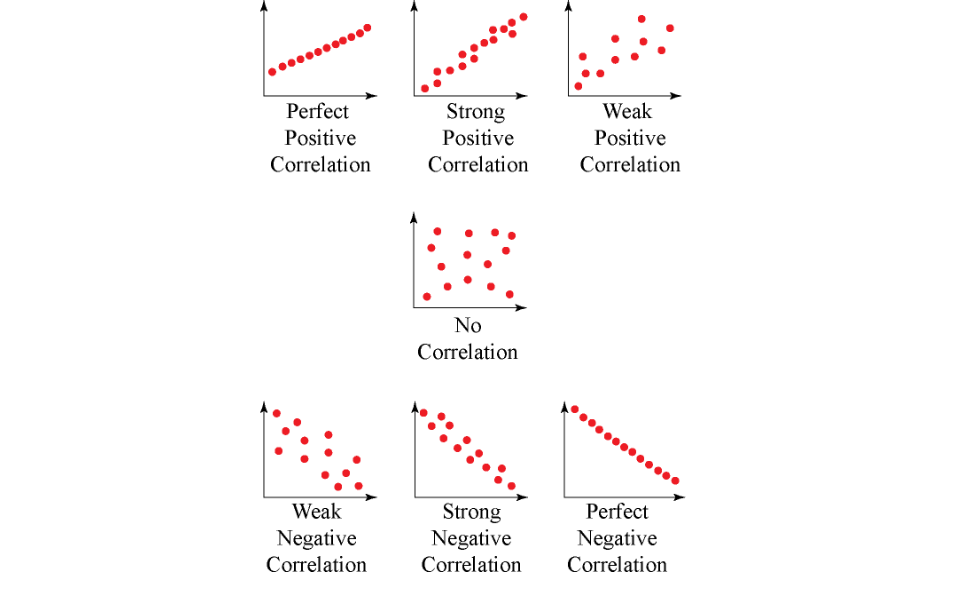

The correlation coefficient has the following formula:

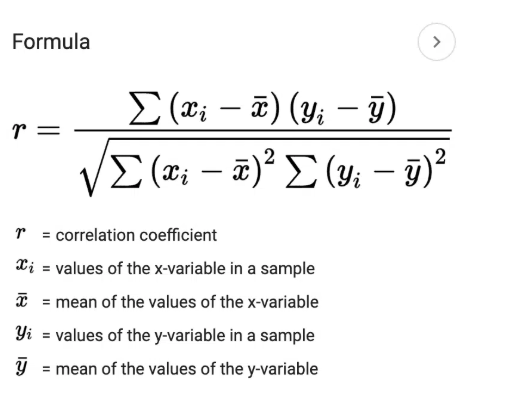

Pandas dataframes also provide a .corr method to compute the correlation coefficients between all pairs of numeric columns.

In [20]:
df.corr(numeric_only = True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


The result of .corr is called a correlation matrix and is often visualized using a heatmap.

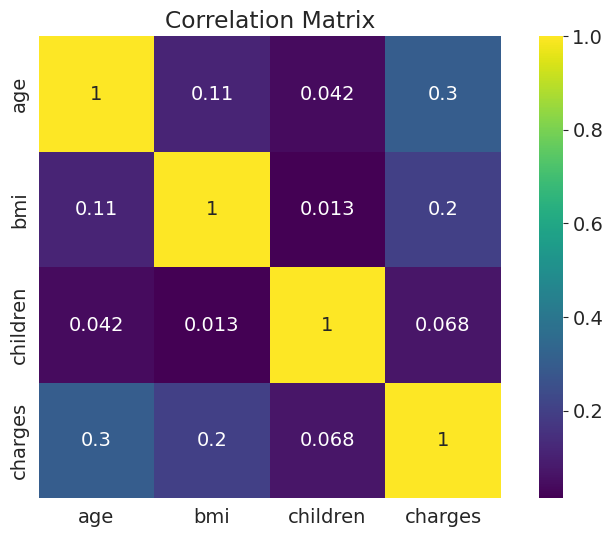

In [21]:
sns.heatmap(df.corr(numeric_only=True),cmap='viridis',annot=True,square=True)
plt.title('Correlation Matrix');

**Correlation vs causation fallacy:** Note that a high correlation cannot be used to interpret a cause-effect relationship between features. Two features X and Y can be correlated if X causes Y or if Y causes X, or if both are caused independently by some other factor Z, and the correlation will no longer hold true if one of the cause-effect relationships is broken. It's also possible that X and Y simply appear to be correlated because the sample is too small.

While this may seem obvious, computers can't differentiate between correlation and causation, and decisions based on automated system can often have major consequences on society, so it's important to study why automated systems lead to a given result. Determining cause-effect of relationships requires human insight.

**Analyze:**

* The correlation matrix shows weak linear relationships with charges and no multicollinearity among predictors. However, correlation averages across subgroups and misses interaction effects, such as BMI affecting charges mainly for smokers.

* Smoking has a strong direct correlation with charges, while BMI and smoking are uncorrelated. However, BMI affects charges conditionally—mainly for smokers—so the effect is not captured by simple correlation, indicating an interaction.

#Train-Test Split

##1. Why do we need a train–test split?
**Core problem**

If we train and evaluate a model on the same data, we will get misleadingly high performance.

This is called:

**Overfitting to seen data**

##Goal of train–test split

To **simulate real-world performance** by testing the model on **unseen data**.

##2. What is train–test split?

You divide your dataset into two parts:

##3. Conceptual intuition
The model learns patterns from training data and is evaluated on test data it has never seen before. This ensures the model generalizes beyond memorization.

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


📌 This prevents data leakage.

#One-hot Encoding

Machine-learning models cannot work with text categories like:

sex = male / female

smoker = yes / no

region = northeast / southwest

one-hot encoding converts them into numeric binary columns:

smoker_yes : 1

somker_no : 0

This is called one-hot encoding.



In [23]:
import pandas as pd

X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)


📌 drop_first=True avoids dummy variable trap.

#Align Train & Test Columns

Sometimes categories appear only in train or test.

In [24]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


Now both have identical columns.

In [25]:
X_train.columns, X_test.columns

(Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
        'region_southeast', 'region_southwest'],
       dtype='object'),
 Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
        'region_southeast', 'region_southwest'],
       dtype='object'))

#Scale Numerical Features

Numeric columns:

* age

* bmi

* children

##Why scale?

* Makes coefficients comparable

* Stabilizes optimization

* Prepares for regularization later

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["age", "bmi", "children"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

⚠️ **Fit only on training data**

✔️ Apply to both

#Train Linear Regression Model

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2:", r2_score(y_test,y_pred))


MAE: 4181.194473753652
MSE: 33596915.85136148
RMSE: 5796.284659276275
R2: 0.7835929767120722


**Analyze:**
The model achieves an R² of 0.78, explaining most of the variance in medical charges. MAE indicates an average error of about ₹4,000, while a higher RMSE suggests the presence of high-cost outliers. Overall, the model performs well but struggles with extreme cases, indicating potential benefits from non-linear modeling or feature interactions.

In [29]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))

train_rmse, test_rmse


(np.float64(6105.545160099847), np.float64(5796.284659276275))

Training and testing RMSE values are close, indicating that the model generalizes well and does not suffer from overfitting. The slightly lower error on the test set is due to randomness in the data split and does not indicate any issue.

#Ranking features by Importance

##what do these coefficients mean?

**Each coefficient tells us how many dollars the medical charge changes when that feature increases by 1 unit, keeping all other features constant.**

**Example:1**

**🚬 smoker_yes = 23651**

This means:

**👉 If a person is a smoker, their predicted medical charges increase by about $23,651**, compared to a non-smoker.

📌 This explains:

* Why smokers form a completely separate cluster

* Why your model struggles with very high charges

Smoking dominates everything.

**Example:2**

**🎂 age = 3615**

This sounds scary:

* A **1-unit increase in age (1 year)** increases charges by ~$3,615

That is **unrealistically large**.

📌 This is a warning sign:

* Age alone cannot increase costs this much

* The model is being distorted by extreme high-charge cases (mostly smokers)


In [31]:
coefficients = pd.DataFrame({'feature':X_train.columns,'weight':model.coef_})
coefficients.sort_values(by='weight',ascending=False)

,feature,weight
4,smoker_yes,23651.128856
0,age,3614.975415
1,bmi,2036.228123
2,children,516.890247
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


Smoking increases predicted charges by more than $23,000, making it the dominant factor. Age and BMI also show very large effects, which suggests that the model is being heavily influenced by extreme high-cost cases.

This makes the coefficients difficult to interpret realistically and indicates that the data contains strong skewness and outliers.

#Residual plot

##What is Residual?

For **each data point**:

**Residual = Actual value - Predicted value**

* **Residual = 0** → perfect prediction

* **Residual > 0** → model **under-predicted**

* **Residual < 0** → model **over-predicted**

**In-simple**

Residuals tells us:
* What is the error
* Where is my model making mistakes?

#Residual vs Prediction

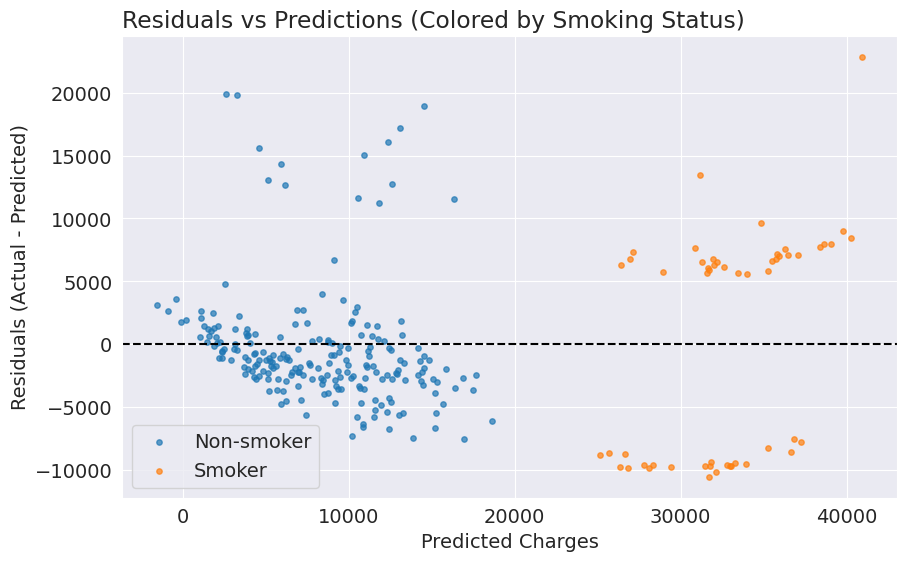

In [32]:
# Calculate residuals
residuals = y_test - y_pred

# Extract smoker status from test set
smoker_status = X_test['smoker_yes']

plt.figure(figsize=(10,6))

# Non-smokers
plt.scatter(
    y_pred[smoker_status == 0],
    residuals[smoker_status == 0],
    s=15,
    alpha=0.7,
    label='Non-smoker'
)

# Smokers
plt.scatter(
    y_pred[smoker_status == 1],
    residuals[smoker_status == 1],
    s=15,
    alpha=0.7,
    label='Smoker'
)

plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predictions (Colored by Smoking Status)", loc='left')
plt.legend()
plt.show()


The residual plot shows clear patterns and increasing variance, indicating heteroscedasticity and missing structure. Large residuals at higher predicted charges suggest that the model underperforms for high-cost individuals, likely smokers. This explains the higher RMSE and indicates that a simple linear model may be insufficient.

#Normality of Residuals

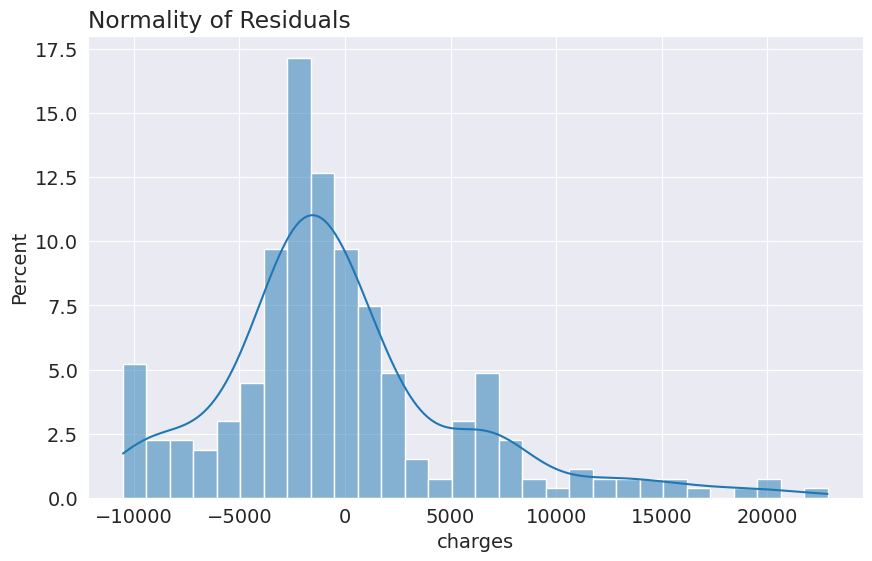

In [33]:
sns.histplot(residuals,kde=True,stat='percent',bins=30,)
plt.title("Normality of Residuals",loc='left')
plt.show()

Residuals are not normally distributed; they are skewed with heavy tails, indicating non-random prediction errors.

# Adding Interaction Features

##What are Interaction Features?

###Normal feature (no interaction)

When we use bmi alone, the model assumes:

**BMI affects medical charges the same way for everyone**

But your EDA clearly showed:

* BMI barely matters **for non-smokers**

* BMI matters **a lot** for **smokers**

That means:

The effect of BMI **depends on smoking status**


##Why interaction features are useful

Interaction features allow **one linear model** to behave like:

* One model for non-smokers

* Another model for smokers

Without actually training two separate models

#Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


##Create interaction features

Create them **after** the split to avoid data leakage.

In [35]:
import pandas as pd

X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)


#Align Train and Test columns

In [36]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [37]:
X_train.columns, X_test.columns

(Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
        'region_southeast', 'region_southwest'],
       dtype='object'),
 Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
        'region_southeast', 'region_southwest'],
       dtype='object'))

In [38]:
# Interaction features
X_train['bmi_smoker'] = X_train['bmi'] * X_train['smoker_yes']
X_train['age_smoker'] = X_train['age'] * X_train['smoker_yes']

X_test['bmi_smoker'] = X_test['bmi'] * X_test['smoker_yes']
X_test['age_smoker'] = X_test['age'] * X_test['smoker_yes']


#Scale numeric features

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["age", "bmi", "children"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

#Train Linear Regression Model

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

#Train and Test Prediction

In [41]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


#Evaluate Model

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("TRAIN PERFORMANCE")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTEST PERFORMANCE")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))


TRAIN PERFORMANCE
MAE: 2974.9562457860484
RMSE: 4893.779724137478
R2: 0.8340713711218875

TEST PERFORMANCE
MAE: 2757.759204250125
RMSE: 4574.1237344513165
R2: 0.8652316979531679


After introducing interaction features between smoking status and continuous variables such as BMI and age, the model performance improved significantly. Test RMSE decreased from approximately $5,800 to $4,600, while the R² score increased to 0.87. This confirms that medical charges are influenced not only by individual factors but also by how these factors interact with smoking behavior.

#Rank Features by Importance

In [43]:
import pandas as pd

coefficients = pd.DataFrame({'features':X_train.columns,'weights':model.coef_})
coefficients.sort_values(by='weights',ascending=False)


,features,weights
0,age,3699.470143
8,bmi_smoker,1470.479368
2,children,562.968514
1,bmi,123.198079
9,age_smoker,1.988728
3,sex_male,-525.595753
5,region_northwest,-631.420972
6,region_southeast,-968.583917
7,region_southwest,-1232.536245
4,smoker_yes,-21271.210909


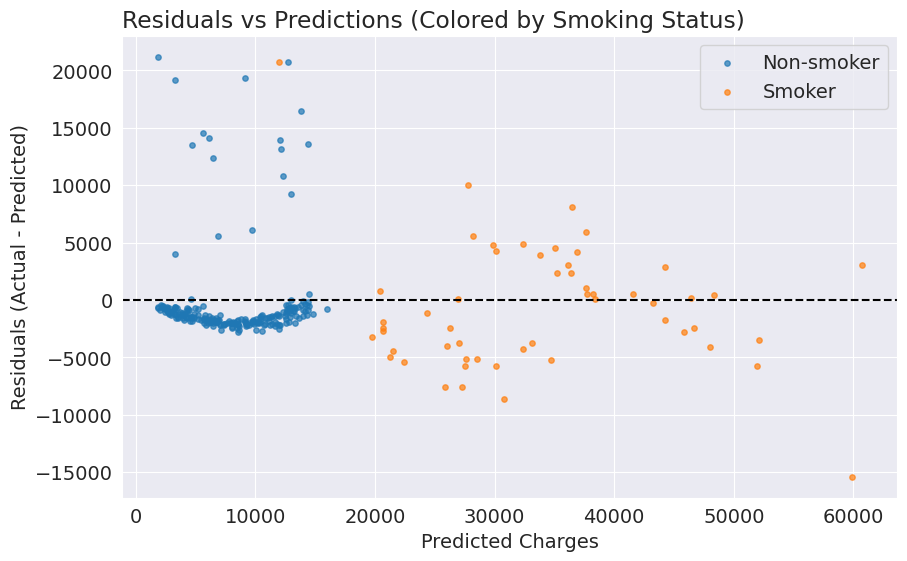

In [44]:
# Calculate residuals
residuals = y_test - y_test_pred

# Extract smoker status from test set
smoker_status = X_test['smoker_yes']

plt.figure(figsize=(10,6))

# Non-smokers
plt.scatter(
    y_test_pred[smoker_status == 0],
    residuals[smoker_status == 0],
    s=15,
    alpha=0.7,
    label='Non-smoker'
)

# Smokers
plt.scatter(
    y_test_pred[smoker_status == 1],
    residuals[smoker_status == 1],
    s=15,
    alpha=0.7,
    label='Smoker'
)

plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predictions (Colored by Smoking Status)", loc='left')
plt.legend()
plt.show()


The residual plot shows that predictions for non-smokers are tightly clustered around zero, indicating good accuracy, while high-cost individuals—predominantly smokers—exhibit large negative residuals, revealing systematic under-prediction for this group.

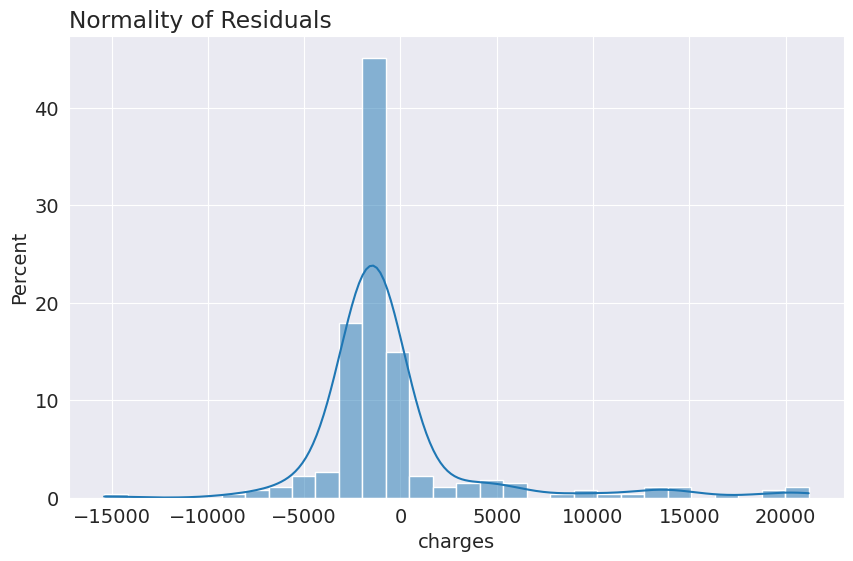

In [45]:
sns.histplot(residuals,kde=True,stat='percent',bins=30,)
plt.title("Normality of Residuals",loc='left')
plt.show()

After adding interaction features, the residuals became more concentrated around zero, indicating improved predictions for most individuals. However, long tails remain due to extreme medical costs, especially among smokers. This suggests that while interaction terms improved model accuracy, the linear model still struggles with rare high-cost cases.

We found that **smoking is the most important factor** affecting medical costs. Age and BMI also matter, but their impact is much stronger for smokers. Adding interaction features like bmi × smoker helped the model understand this better and improved performance.

Even after these improvements, the model still struggles to predict **very high medical charges**, especially for smokers. This happens because linear regression cannot capture complex, non-linear patterns.

Overall, linear regression works well as a **simple and interpretable baseline**, but more advanced models are needed for better accuracy on high-cost cases.

**In one-line**

Linear regression explains medical charges reasonably well, but fails for extreme cases.

#SGDRegressor(Stochastic Gradient Descent)

##Why move from Linear Regression to SGDRegressor?

So far, we trained a **closed-form Linear Regression** model.

It works well for average cases but struggles with **high-cost individuals**, especially smokers.

This is where **Stochastic Gradient Descent (SGD)** helps.

##🧠 What is Stochastic Gradient Descent (SGD)?

Think of SGD as **learning step-by-step instead of solving everything at once**.

**Simple explanation:**

* Linear Regression finds the best weights using a **mathematical formula**

* SGD finds the weights by:

**1.** Making a prediction

**2.** Calculating the error

**3.** Slightly adjusting the weights

**4.** Repeating this many times

Instead of using the whole dataset at once, **SGD updates weights using small batches or single rows**.

##Why SGD can help here

SGD is useful when:

* Data has **outliers** (like very high medical charges)

* Relationships are **not perfectly linear**

* We want more **control** over learning (learning rate, regularization)

SGD also allows **regularization (L1 / L2)**, which helps reduce overfitting.

##⚠️ Important: Scaling is mandatory

SGD is **very sensitive to feature scales**.
So we **must scale the data first**.

##SGDRegressor — Step by Step Code

Below is **clean, simple code**.

In [46]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


#Scaling

In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#Create Model

In [48]:
sgd_model = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    penalty='l2',      # regularization
    alpha=0.0001,      # strength of regularization
    learning_rate='invscaling',
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)


SGDRegressor(random_state=42)

In [49]:
y_train_pred = sgd_model.predict(X_train_scaled)
y_test_pred = sgd_model.predict(X_test_scaled)


#Evaluation

In [50]:
def evaluate(y_true, y_pred, label):
    print(f"{label} PERFORMANCE")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2  :", r2_score(y_true, y_pred))
    print()

evaluate(y_train, y_train_pred, "TRAIN")
evaluate(y_test, y_test_pred, "TEST")


TRAIN PERFORMANCE
MAE : 2954.030563879598
RMSE: 4903.826377249449
R2  : 0.8333893876137485

TEST PERFORMANCE
MAE : 2755.6993871180366
RMSE: 4564.203029197854
R2  : 0.8658156553579136



After applying SGDRegressor, the model performance remained almost unchanged compared to standard Linear Regression. This confirms that the main limitation is not the optimization method but the linear assumption of the model itself. Even with better training strategies, linear models struggle to capture the complex patterns behind high medical charges.

##Final Conclusion

In this project, we explored the dataset in depth, tried multiple preprocessing strategies, applied log transformations, added interaction features, and tested both Linear Regression and SGDRegressor. While these steps improved the model and helped us better understand the data, the results clearly show that linear models struggle to fully capture the complexity of high medical charges—especially for high-cost individuals like smokers.

This doesn’t mean the analysis failed. In fact, it succeeded in doing something more important: **showing the limits of linear models** and teaching us why more advanced, non-linear models are needed for this problem.

With a solid understanding of the data, features, and model behavior, we now have a strong foundation to move forward and build more powerful models.

Thanks for reading, and happy learning! 🚀

you can check out our [project](https://medical-insurance-cost-prediction-cjf4uptd44r6c93bjahsen.streamlit.app/).